In [ ]:
import re
from pathlib import Path
import pandas as pd
from multiprocessing import Pool, cpu_count

#on utilise spacy
USE_SPACY = True
try:
    import spacy
    nlp = spacy.load("fr_core_news_md")
except:
    USE_SPACY = False

#on charge un dataset de prénoms français qui servira pour la détection de genre
try:
    import json
    with open("prenoms_fr.json", encoding="utf-8") as f:
        PRENOMS = json.load(f)
except:
    PRENOMS = {}

#on nettoie le texte pour faciliter les analyses ultérieures
def clean_text(text):
    text = text.lower()
    text = re.sub(r"\n+", " ", text)
    text = re.sub(r"[^a-zàâéèêîôûç0-9 ]", " ", text)
    return text

#récupérer le nom, prénom du candidat
import re
import unicodedata

def extract_candidate(text, PRENOMS):

    def normalize(s):
        s = s.lower()
        s = unicodedata.normalize("NFD", s)
        s = "".join(c for c in s if unicodedata.category(c) != "Mn")
        return re.sub(r"[^a-z\- ]", "", s)

    def is_name_token(w):
        w_norm = normalize(w)
        return w_norm in PRENOMS

    BAD_WORDS = {
        "votez", "elections", "legislatives", "circonscription",
        "suppléante", "suppléant", "maire", "adjoint",
        "socialiste", "republique", "gauche", "droite"
    }

    lines = text.split("\n")

    candidates = []

    for line in lines:
        raw = line.strip()
        if not raw:
            continue

        # split tokens
        words = re.findall(r"[A-Za-zÀ-ÿ\-]+", raw)

        if not (2 <= len(words) <= 4):
            continue

        norm_words = [normalize(w) for w in words]

        # skip slogans / bruit
        if any(w in BAD_WORDS for w in norm_words):
            continue

        score = 0

        # BONUS: format NOM prénom ou Prénom NOM
        cap_words = sum(1 for w in words if w[0].isupper())
        score += cap_words

        # BONUS prénom détecté
        if words and is_name_token(words[0]):
            score += 2

        if len(words) >= 2 and is_name_token(words[1]):
            score += 2

        # BONUS ligne courte = souvent nom candidat
        if len(words) == 2:
            score += 2

        # BONUS majuscules typiques affiches
        if all(w.isupper() for w in words):
            score += 2

        if score >= 3:
            candidates.append((" ".join(words), score))

    if not candidates:
        return None

    candidates.sort(key=lambda x: x[1], reverse=True)
    return candidates[0][0].upper()

#fonction pour deviner le genre à partir du prénom
def guess_gender(name):
    if not name:
        return None

    first_name = name.split()[0].lower()

    if first_name in PRENOMS:
        return PRENOMS[first_name]

    # au cas où une dernière heuristique
    if first_name.endswith("e"):
        return "female"
    return "male"

#ici pour retrouver le parti politique, on peut faire une liste de mots-clés
PARTIES = [
    "PSU", "PS", "PCF", "RPR", "UDF", "FN", "LREM",
    "PARTI SOCIALISTE", "PARTI COMMUNISTE",
    "GAULLISTE"
]

def extract_party(text):
    text_upper = text.upper()

    if "PS" in text_upper or "PARTI SOCIALISTE" in text_upper:
        return "PS"

    if "PCF" in text_upper or "PARTI COMMUNISTE" in text_upper:
        return "PCF"

    for party in PARTIES:
        if party in text_upper:
            return party

    return None

#pareil pour le soutien, on cherche des expressions clés
def extract_support(text):
    match = re.search(
        r"(investi par|soutenu par|candidat de|avec le soutien de)\s*[:\-]?\s*(.+?)(\.|\n)",
        text,
        re.IGNORECASE
    )
    return match.group(2).strip() if match else None

#on est maintenant prêt à extraire toutes les métadonnées d'un texte donné
def extract_metadata(text):
    metadata = {}
    PRENOMS = {

    #male names
    "aaron": "male", "abdel": "male", "adam": "male", "adrien": "male",
    "ahmed": "male", "alain": "male", "alban": "male", "alex": "male",
    "alexandre": "male", "alexis": "male", "ali": "male", "amadou": "male",
    "andre": "male", "andré": "male", "anthony": "male", "antoine": "male",
    "arnaud": "male", "arthur": "male", "axel": "male", "aymeric": "male",
    "baptiste": "male", "benjamin": "male", "bernard": "male",
    "brice": "male", "bruno": "male", "cedric": "male", "cédric": "male",
    "charles": "male", "christian": "male", "christophe": "male",
    "clement": "male", "clément": "male", "damien": "male", "daniel": "male",
    "david": "male", "denis": "male", "didier": "male", "dominique": "male",
    "edouard": "male", "édouard": "male", "emmanuel": "male",
    "enzo": "male", "eric": "male", "éric": "male", "etienne": "male",
    "étienne": "male", "fabien": "male", "fabrice": "male",
    "florian": "male", "franck": "male", "francis": "male",
    "francois": "male", "françois": "male", "frederic": "male",
    "frédéric": "male", "gabriel": "male", "gael": "male", "gaël": "male",
    "gaspard": "male", "gerard": "male", "gérard": "male",
    "guillaume": "male", "guy": "male", "hugo": "male",
    "ismail": "male", "jacques": "male", "jean": "male",
    "jeremy": "male", "jérémy": "male", "jerome": "male",
    "jérôme": "male", "jonathan": "male", "joseph": "male",
    "julien": "male", "kevin": "male", "laurent": "male",
    "leo": "male", "léo": "male", "lionel": "male", "loic": "male",
    "loïc": "male", "luc": "male", "lucas": "male", "ludovic": "male",
    "marc": "male", "marcel": "male", "marius": "male",
    "mathieu": "male", "mathis": "male", "maxime": "male",
    "mehdi": "male", "michael": "male", "michel": "male",
    "mohamed": "male", "nabil": "male", "nathan": "male",
    "nicolas": "male", "noah": "male", "olivier": "male",
    "oscar": "male", "pascal": "male", "patrick": "male",
    "paul": "male", "pierre": "male", "quentin": "male",
    "raphael": "male", "raphaël": "male", "raymond": "male",
    "remi": "male", "rémi": "male", "renaud": "male",
    "robert": "male", "romain": "male", "samuel": "male",
    "sebastien": "male", "sébastien": "male", "serge": "male",
    "stephane": "male", "stéphane": "male", "sylvain": "male",
    "thibault": "male", "thomas": "male", "thierry": "male",
    "valentin": "male", "victor": "male", "vincent": "male",
    "yann": "male", "yohan": "male", "yves": "male",

    #female names
    "adele": "female", "adèle": "female", "agnes": "female",
    "agnès": "female", "aicha": "female", "alexandra": "female",
    "alexia": "female", "alice": "female", "aline": "female",
    "amandine": "female", "amelie": "female", "amélie": "female",
    "anais": "female", "anaïs": "female", "andree": "female",
    "andrée": "female", "angelique": "female", "angélique": "female",
    "anne": "female", "annick": "female", "audrey": "female",
    "aurelie": "female", "aurélie": "female", "beatrice": "female",
    "béatrice": "female", "bernadette": "female", "brigitte": "female",
    "camille": "female", "caroline": "female", "catherine": "female",
    "celine": "female", "céline": "female", "chantal": "female",
    "charlotte": "female", "chloe": "female", "chloé": "female",
    "christine": "female", "claire": "female", "claudine": "female",
    "corinne": "female", "delphine": "female", "dominique": "female",
    "edith": "female", "elise": "female", "élise": "female",
    "elodie": "female", "élodie": "female", "emma": "female",
    "emmanuelle": "female", "estelle": "female", "eva": "female",
    "fabienne": "female", "florence": "female", "francoise": "female",
    "françoise": "female", "geraldine": "female", "géraldine": "female",
    "helene": "female", "hélène": "female", "isabelle": "female",
    "jade": "female", "jacqueline": "female", "jeanne": "female",
    "julie": "female", "karine": "female", "laetitia": "female",
    "laëtitia": "female", "laura": "female", "lea": "female",
    "léa": "female", "lila": "female", "lina": "female",
    "louise": "female", "lucie": "female", "madeleine": "female",
    "manon": "female", "marie": "female", "marine": "female",
    "martine": "female", "melanie": "female", "mélanie": "female",
    "monique": "female", "nadine": "female", "nathalie": "female",
    "nicole": "female", "noemie": "female", "noémie": "female",
    "oceane": "female", "océane": "female", "pauline": "female",
    "sabrina": "female", "sarah": "female", "sophie": "female",
    "stephanie": "female", "stéphanie": "female", "sylvie": "female",
    "valerie": "female", "valérie": "female", "vanessa": "female",
    "veronique": "female", "véronique": "female", "victoria": "female",
    "virginie": "female", "zoe": "female", "zoé": "female"
    }
    text_upper = text.upper()

    # YEAR
    year_match = re.search(r"(19|20)\d{2}", text)
    metadata["year"] = year_match.group(0) if year_match else None

    # TYPE
    if "LÉGISLATIVES" in text_upper or "LEGISLATIVES" in text_upper:
        metadata["type_election"] = "legislatives"
    elif "PRÉSIDENTIELLE" in text_upper or "PRESIDENTIELLE" in text_upper:
        metadata["type_election"] = "presidentielle"
    else:
        metadata["type_election"] = None

    # CANDIDATE
    candidate = extract_candidate(text, PRENOMS)
    metadata["candidate"] = candidate

    # GENDER
    metadata["gender"] = guess_gender(candidate)

    # PARTY
    metadata["party_list"] = extract_party(text)

    # SUPPORT
    metadata["titulaire_soutien"] = extract_support(text)

    return metadata

#fonction pour convertir un fichier texte en une ligne de dataframe avec les métadonnées extraites
def process_file(file_path):
    try:
        raw_text = file_path.read_text(encoding="utf-8", errors="ignore")

        meta = extract_metadata(raw_text)
        cleaned = clean_text(raw_text)

        return {
            "text": cleaned,
            "filename": file_path.stem,
            **meta
        }
    except Exception as e:
        return {
            "text": None,
            "filename": file_path.stem,
            "error": str(e)
        }

#construction du dataframe sur lequel on va travailler
def build_dataframe(base_path="text_files"):
    base = Path(base_path)

    files = list(base.glob("**/*.txt"))

    print(f"{len(files)} files found")

    with Pool(cpu_count()) as p:
        data = p.map(process_file, files)

    df = pd.DataFrame(data)

    return df

df = build_dataframe()

21697 files found


In [ ]:
print(df.gender.head(50))

#here we can do a little bit of descriptive statistics
def describe_dataframe(df):
    print("Dimension du dataframe :", df.shape)

    print("\nValeurs manquantes :")
    print(df.isna().sum())

    print("\nNombre de types d'élection :")
    print(df["type_election"].value_counts(dropna=False))

    print("\nNombre de chaque genre :")
    print(df["gender"].value_counts(dropna=False))

    print("\nNombre pour chaque année :")
    print(df["year"].value_counts().sort_index())

    print("\nNombre de chaque parti (10 meilleurs):")
    print(df["party_list"].value_counts().head(10))

    print("\nNombre de chaque soutien (10 meilleurs):")
    print(df["titulaire_soutien"].value_counts().head(10))

    print("Unique candidates:", df["candidate"].nunique())
    print("Missing candidates:", df["candidate"].isna().sum())

    print("\nInfos sur les textes :")
    df["text_length"] = df["text"].apply(lambda x: len(x) if isinstance(x, str) else 0)
    print(df["text_length"].describe())

    print("\nInfos sur les mots :")
    df["word_count"] = df["text"].apply(lambda x: len(x.split()) if isinstance(x, str) else 0)
    print(df["word_count"].describe())

describe_dataframe(df)

                                                 text  \
0   sciences po   fonds cevipof élections législat...   
1   sciences po   fonds cevipof élections législat...   
2   sciences po   fonds cevipof république françai...   
3     elections legislatives de mars 1978 7  circo...   
4   an ekolojisted a sav o mouez     evid ma ne vi...   
5   sciences po   fonds cevipof union pour la nouv...   
6   république française département de la haute v...   
7   sciences po   fonds cevipov elections législat...   
8   elections législatives   mars 1978   3e circon...   
9   sciences po   fonds cevipof république françai...   
10  elections legislatives du 12 mars 1978 departe...   
11  sciences po   fonds cevipof élections législat...   
12  sciences po   fonds cevipof republique françai...   
13  3e circonscription de l aube election legislat...   
14  sciences po   fonds cevipof maire de chateauli...   
15  elections legislatives du 12 mars 1978   3e ci...   
16  elections legislatives des 

<Axes: xlabel='party_list', ylabel='Count'>

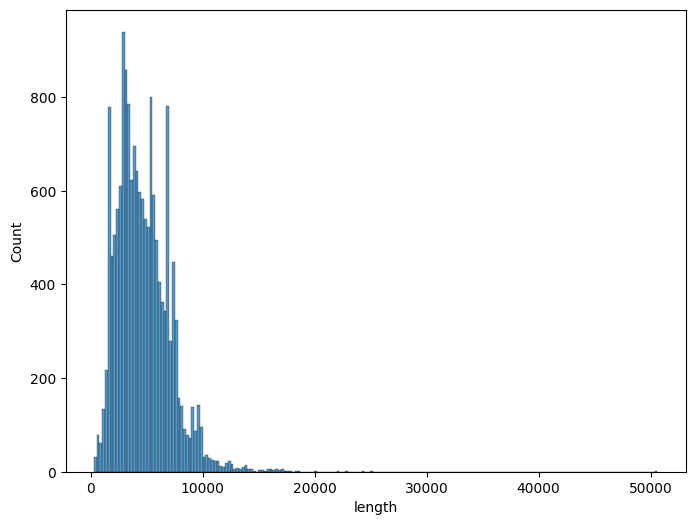

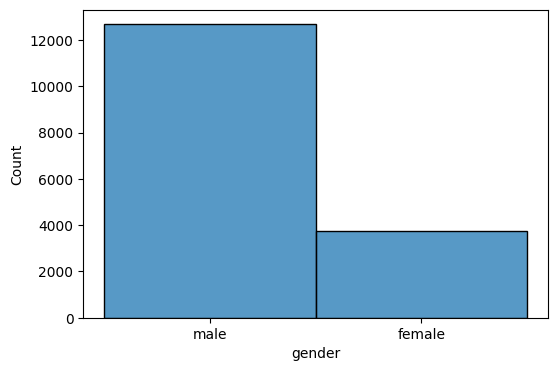

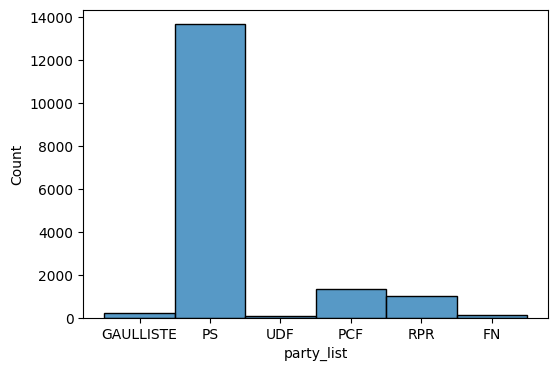

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

#we visualize the distribution of text lengths
df["length"] = df["text"].apply(len)
plt.figure(figsize=(8, 6))
sns.histplot(df["length"])

#now we can look at the distribution of genders on anoither histogram
plt.figure(figsize=(6, 4))
sns.histplot(df["gender"])

#now we can look at the distribution of potitical parties on anoither histogram
plt.figure(figsize=(6, 4))
sns.histplot(df["party_list"])

In [48]:
#detecting gender style using logistic regression on the text
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

#on enlève là où le genre est manquant
df = df.dropna(subset=["gender"])

X_train, X_test, y_train, y_test = train_test_split(
    df["text"], df["gender"], test_size=0.3
)

vectorizer = CountVectorizer(max_features=2000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)


clf = LogisticRegression(max_iter=5000)
clf.fit(X_train_vec, y_train)
print("Accuracy:", clf.score(X_test_vec, y_test))

Accuracy: 0.7630937880633374


              precision    recall  f1-score   support

      female       0.50      0.41      0.45      1161
        male       0.83      0.87      0.85      3765

    accuracy                           0.76      4926
   macro avg       0.66      0.64      0.65      4926
weighted avg       0.75      0.76      0.75      4926



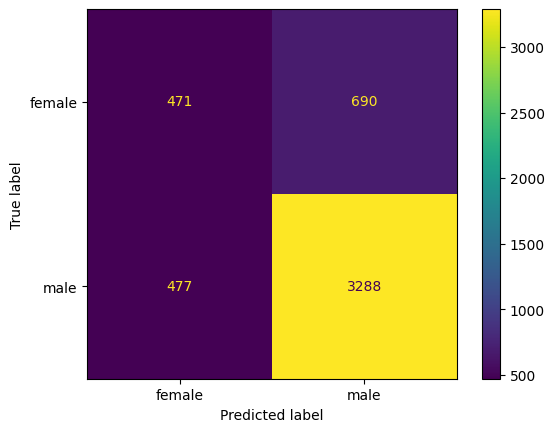

In [49]:
#accuracy is mid, we can try to look at the confusion matrix to see where it fails
#creating confusion matrix for the gender classification

from sklearn.metrics import classification_report, ConfusionMatrixDisplay

y_pred = clf.predict(X_test_vec)

print(classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

Accuracy: 0.7831912302070646
              precision    recall  f1-score   support

      female       0.64      0.19      0.29      1161
        male       0.79      0.97      0.87      3765

    accuracy                           0.78      4926
   macro avg       0.71      0.58      0.58      4926
weighted avg       0.76      0.78      0.73      4926



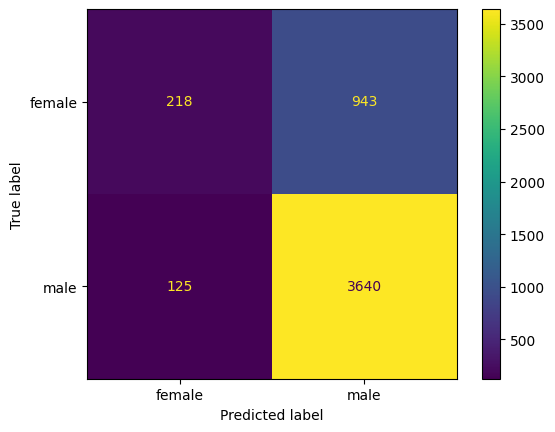

In [50]:

#we can try to improve the results using TfidfVectorizer instead of CountVectorizer

vectorizer = TfidfVectorizer(max_features=2000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

clf = MultinomialNB()
clf.fit(X_train_vec, y_train)

print("Accuracy:", clf.score(X_test_vec, y_test))


y_pred = clf.predict(X_test_vec)

print(classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

In [ ]:
#it's way worse, female candidates are often misclassified as male

In [52]:
#detecting party style using multinomial naive bayes on the text

#on enlève là où le parti est manquant
df = df.dropna(subset=["party_list"])

X_train, X_test, y_train, y_test = train_test_split(
    df["text"], df["party_list"], test_size=0.2
)

vectorizer = CountVectorizer(max_features=2000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

clf = MultinomialNB()
clf.fit(X_train_vec, y_train)

print("Accuracy:", clf.score(X_test_vec, y_test))

Accuracy: 0.5621193666260658


In [53]:
#accuracy is around 0.56 which is not great, we try something else
#same for TfidfVectorizer instead of CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=2000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

clf = MultinomialNB()
clf.fit(X_train_vec, y_train)

print("Accuracy:", clf.score(X_test_vec, y_test))

Accuracy: 0.8300852618757613


              precision    recall  f1-score   support

          FN       0.06      0.12      0.08        25
   GAULLISTE       0.00      0.00      0.00        46
         PCF       1.00      0.10      0.17       272
          PS       0.85      0.98      0.91      2729
         RPR       0.40      0.11      0.17       195
         UDF       0.00      0.00      0.00        17

    accuracy                           0.83      3284
   macro avg       0.39      0.22      0.22      3284
weighted avg       0.81      0.83      0.78      3284



/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape

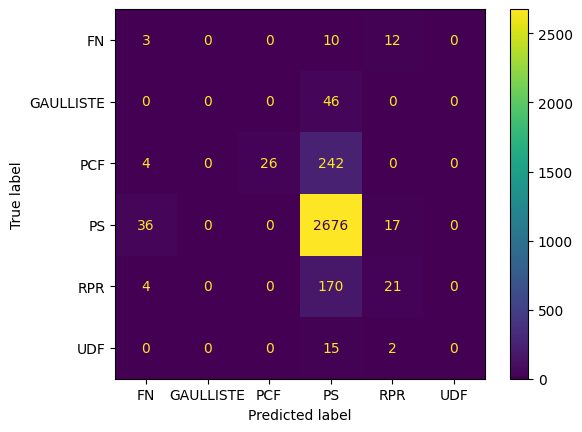

In [54]:
#it's a little bit better but still not great, we can try to look at the confusion matrix to see where it fails
#creating confusion matrix for the party classification

y_pred = clf.predict(X_test_vec)

print(classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 8817.52it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 514/514 [14:29<00:00,  1.69s/it]
/usr/local/python/3.12.1/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


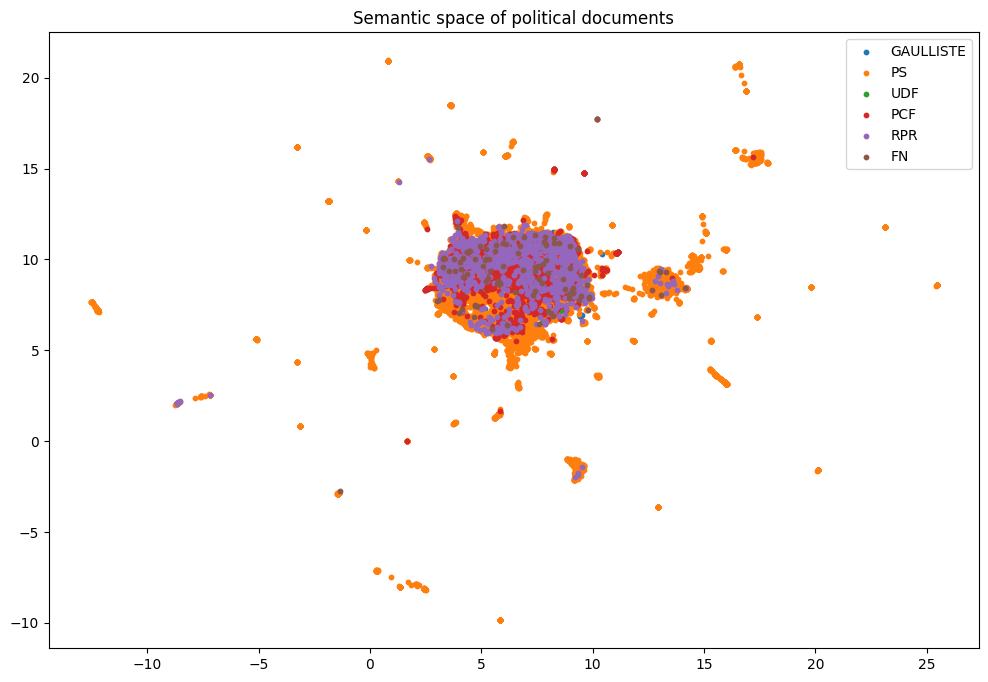

In [ ]:
#now we try to visualize in 2D the text embeddigns for semantic similarity, with party/potitical support
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt
import umap
model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

embeddings = model.encode(df["text"].fillna("").tolist(), show_progress_bar=True)

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42
)

embedding_2d = reducer.fit_transform(embeddings)

df["x"] = embedding_2d[:, 0]
df["y"] = embedding_2d[:, 1]

#each color represents a party list
plt.figure(figsize=(12, 8))

for label in df["party_list"].fillna("UNKNOWN").unique():
    subset = df[df["party_list"] == label]
    plt.scatter(subset["x"], subset["y"], label=label, s=10)

plt.legend()
plt.title("Semantic space of political documents for each political party")
plt.show()


#each color represents a gender
plt.figure(figsize=(12, 8))

for label in df["gender"].fillna("UNKNOWN").unique():
    subset = df[df["gender"] == label]
    plt.scatter(subset["x"], subset["y"], label=label, s=10)

plt.legend()
plt.title("Semantic space of political documents for each gender")
plt.show()


#each color represents a support structure
plt.figure(figsize=(12, 8))

for label in df["titulaire_soutien"].fillna("UNKNOWN").unique():
    subset = df[df["titulaire_soutien"] == label]
    plt.scatter(subset["x"], subset["y"], label=label, s=10)

plt.legend()
plt.title("Semantic space of political documents for each support structure")
plt.show()

In [2]:
#last thing to do is to identify outliers of the semantic space

from sklearn.metrics import pairwise_distances
import numpy as np

dist = pairwise_distances(embedding_2d, metric="euclidean")

mean_dist = dist.mean(axis=1)
df["outlier_score"] = mean_dist

outliers = df.sort_values("outlier_score", ascending=False).head(20)

plt.figure(figsize=(12, 8))

plt.scatter(df["x"], df["y"], s=10, alpha=0.5)

plt.scatter(
    outliers["x"],
    outliers["y"],
    color="red",
    s=50,
    label="Outliers"
)

plt.legend()
plt.title("Semantic space with outliers")
plt.show()

NameError: name 'embedding_2d' is not defined